# Garnet MDP benchmark with 10 independent MDPs

Runs VI, SR, shared-goal Q-learning, and ECM for the three requested configurations. Every repeat uses a different random MDP seed. Raw checkpoints, seeds, aggregate means, and standard deviations are saved under `./data`.

In [16]:
# -*- coding: utf-8 -*-
import os
import csv
import json
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

try:
    import torch
except ImportError as exc:
    raise ImportError("This notebook needs PyTorch. Install torch first.") from exc

try:
    from numba import njit
    NUMBA_AVAILABLE = True
except ImportError:
    NUMBA_AVAILABLE = False
    warnings.warn(
        "Numba is unavailable. SR and Q-learning remain correct, but their "
        "exact sequential updates will run much more slowly."
    )

    def njit(func=None, **kwargs):
        if func is None:
            return lambda f: f
        return func

# Shared benchmark settings
DATA_DIR = "./data_test"
NUM_REPEATS = 10
OVERWRITE_EXISTING = False

HORIZON = 100
ROLLOUTS_PER_PAIR = 1
BATCH_SIZE = 2048
STREAM_CHUNK_SIZE = 4096

GARNET_BRANCHING = 2
GARNET_PROB_METHOD = "dirichlet"
GARNET_ALPHA = 0.8
GARNET_ALLOW_SELF_LOOPS = False
GARNET_BACKBONE_ACTION = 0

VI_ITERS = list(range(1, 21)) + [30, 50, 100, 200]

ENA_MAC_MODE = "states"
SR_MACS_PER_TRANSITION_FACTOR = 2

Q_ALPHA = 0.1
Q_GAMMA = 1.0
Q_TIE_NOISE = 1e-6
Q_MACS_PER_GOAL_UPDATE_FACTOR = 2

os.makedirs(DATA_DIR, exist_ok=True)

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("CUDA device:", torch.cuda.get_device_name(0))

Using device: cuda
CUDA device: NVIDIA RTX PRO 4000 Blackwell


In [17]:
# ──────────────────────────────────────────────────────────────────────────────
# Results helpers and Garnet MDP builder
# ──────────────────────────────────────────────────────────────────────────────
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def write_curve_csv(path, rows):
    ensure_dir(os.path.dirname(path))
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["checkpoint", "macs", "success", "steps"])
        for r in rows:
            w.writerow(r)

def aggregate_curves(curves):
    arr = np.stack(curves, axis=0)  # repeats, checkpoints, columns
    mean = arr.mean(axis=0)
    ddof = 1 if arr.shape[0] > 1 else 0
    std = arr.std(axis=0, ddof=ddof)
    return pd.DataFrame({
        "checkpoint_mean": mean[:,0],
        "checkpoint_std":  std[:,0],
        "macs_mean":       mean[:,1],
        "macs_std":        std[:,1],
        "success_mean":    mean[:,2],
        "success_std":     std[:,2],
        "steps_mean":      mean[:,3],
        "steps_std":       std[:,3],
    })

def save_aggregate(name, curves, output_dir):
    df = aggregate_curves(curves)
    path = os.path.join(output_dir, f"{name}_aggregate.csv")
    df.to_csv(path, index=False)
    return df

def is_strongly_connected_from_edges(n_states, edges):
    fwd = [[] for _ in range(n_states)]
    rev = [[] for _ in range(n_states)]
    for u, v in edges:
        fwd[u].append(v)
        rev[v].append(u)

    def visit(graph, start=0):
        seen = np.zeros(n_states, dtype=bool)
        stack = [start]
        seen[start] = True
        while stack:
            u = stack.pop()
            for v in graph[u]:
                if not seen[v]:
                    seen[v] = True
                    stack.append(v)
        return seen

    return bool(visit(fwd).all() and visit(rev).all())

def _sample_garnet_probabilities(rng, k, method="partition", alpha=1.0):
    if method == "partition":
        cuts = np.sort(rng.random(k - 1)) if k > 1 else np.array([])
        pts = np.concatenate([[0.0], cuts, [1.0]])
        probs = np.diff(pts)
        rng.shuffle(probs)
        return probs.astype(np.float64)
    if method == "dirichlet":
        return rng.dirichlet(np.full(k, float(alpha))).astype(np.float64)
    raise ValueError("prob_method must be 'partition' or 'dirichlet'.")

def build_mdp_garnet_strongly_connected(
    n_states,
    n_actions=2,
    branching=2,
    prob_method="dirichlet",
    alpha=0.8,
    allow_self_loops=False,
    backbone_action=0,
    seed=0,
):
    if n_states < 3:
        raise ValueError("Need n_states >= 3.")
    if n_actions < 1:
        raise ValueError("Need at least one action.")
    if not (0 <= backbone_action < n_actions):
        raise ValueError("backbone_action must be a valid action index.")
    if branching < 1:
        raise ValueError("branching must be >= 1.")

    rng = np.random.default_rng(seed)
    max_successors = n_states if allow_self_loops else n_states - 1
    branching = int(min(max(1, branching), max_successors))

    perm = rng.permutation(n_states)
    cycle_next = np.empty(n_states, dtype=np.int64)
    for i, u in enumerate(perm):
        cycle_next[u] = perm[(i + 1) % n_states]

    P = np.zeros((n_actions, n_states, n_states), dtype=np.float64)
    support_edges = []
    forced_backbone_edges = []
    successor_counts = []
    all_states = np.arange(n_states, dtype=np.int64)

    for s in range(n_states):
        candidates = all_states if allow_self_loops else all_states[all_states != s]
        for a in range(n_actions):
            succ = set()
            if a == backbone_action:
                v = int(cycle_next[s])
                succ.add(v)
                forced_backbone_edges.append((s, v))
            while len(succ) < branching:
                succ.add(int(rng.choice(candidates)))
            succ = np.array(sorted(succ), dtype=np.int64)
            probs = _sample_garnet_probabilities(rng, len(succ), method=prob_method, alpha=alpha)
            P[a, s, succ] = probs
            successor_counts.append(len(succ))
            support_edges.extend((s, int(v)) for v in succ)

    P /= P.sum(axis=2, keepdims=True)

    info = {
        "generator": "garnet_strongly_connected",
        "n_states": int(n_states),
        "n_actions": int(n_actions),
        "branching": int(branching),
        "prob_method": prob_method,
        "alpha": float(alpha),
        "allow_self_loops": bool(allow_self_loops),
        "backbone_action": int(backbone_action),
        "backbone_strongly_connected": is_strongly_connected_from_edges(n_states, forced_backbone_edges),
        "support_strongly_connected": is_strongly_connected_from_edges(n_states, support_edges),
        "successors_per_state_action_min": int(np.min(successor_counts)),
        "successors_per_state_action_mean": float(np.mean(successor_counts)),
        "successors_per_state_action_max": int(np.max(successor_counts)),
    }
    return P, info

def est_sparse_k(P):
    return float((P > 0).sum(axis=2).mean())

In [18]:
# ──────────────────────────────────────────────────────────────────────────────
# Sparse outcome tables, batched sampling, and rollout evaluation
# ──────────────────────────────────────────────────────────────────────────────
def precompute_sparse_outcomes(P, device):
    n_actions, n_states, _ = P.shape
    k_max = int((P > 0).sum(axis=2).max())
    outcome_states = np.zeros((n_actions, n_states, k_max), dtype=np.int64)
    outcome_cdf = np.ones((n_actions, n_states, k_max), dtype=np.float64)
    for a in range(n_actions):
        for s in range(n_states):
            idx = np.flatnonzero(P[a, s] > 0)
            probs = P[a, s, idx]
            cdf = np.cumsum(probs)
            cdf[-1] = 1.0
            outcome_states[a, s, :len(idx)] = idx
            outcome_states[a, s, len(idx):] = idx[-1]
            outcome_cdf[a, s, :len(idx)] = cdf
            outcome_cdf[a, s, len(idx):] = 1.0
    return (
        torch.as_tensor(outcome_states, dtype=torch.long, device=device),
        torch.as_tensor(outcome_cdf, dtype=torch.float32, device=device),
    )

def sample_next_states(outcome_states, outcome_cdf, actions, states):
    cdf = outcome_cdf[actions, states]
    r = torch.rand(actions.shape, device=actions.device)
    k = torch.sum(r.unsqueeze(-1) > cdf, dim=-1)
    return outcome_states[actions, states, k]

@torch.no_grad()
def generate_episode_batch(batch_size, episode_len, n_states, n_actions,
                           outcome_states, outcome_cdf, device):
    traj = torch.empty((batch_size, episode_len + 1), dtype=torch.long, device=device)
    acts = torch.empty((batch_size, episode_len), dtype=torch.long, device=device)
    traj[:, 0] = torch.randint(n_states, (batch_size,), device=device)
    for t in range(episode_len):
        a = torch.randint(n_actions, (batch_size,), device=device)
        acts[:, t] = a
        traj[:, t + 1] = sample_next_states(outcome_states, outcome_cdf, a, traj[:, t])
    return traj, acts

@torch.no_grad()
def evaluate_policy_rollout_torch(Pi, outcome_states, outcome_cdf, horizon, n_rollouts, device):
    """Return success rate and capped mean steps. Failures count as horizon."""
    n_states = Pi.shape[0]
    starts = []
    goals = []
    for s in range(n_states):
        for g in range(n_states):
            if s != g:
                starts.append(s)
                goals.append(g)
    starts = torch.as_tensor(starts, dtype=torch.long, device=device)
    goals = torch.as_tensor(goals, dtype=torch.long, device=device)
    if n_rollouts > 1:
        starts = starts.repeat_interleave(n_rollouts)
        goals = goals.repeat_interleave(n_rollouts)

    states = starts.clone()
    steps = torch.full_like(states, fill_value=horizon)
    success = torch.zeros(states.shape, dtype=torch.bool, device=device)
    active = torch.ones(states.shape, dtype=torch.bool, device=device)

    for t in range(1, horizon + 1):
        if not bool(active.any()):
            break
        active_idx = torch.nonzero(active, as_tuple=False).flatten()
        s_now = states[active_idx]
        g_now = goals[active_idx]
        a_now = Pi[s_now, g_now]
        s_next = sample_next_states(outcome_states, outcome_cdf, a_now, s_now)
        states[active_idx] = s_next
        hit = s_next == g_now
        if bool(hit.any()):
            hit_idx = active_idx[hit]
            steps[hit_idx] = t
            success[hit_idx] = True
            active[hit_idx] = False

    return float(success.float().mean().item()), float(steps.float().mean().item())


# NumPy versions used by the exact sequential SR and Q-learning streams.
def precompute_sparse_outcomes_numpy(P):
    n_actions, n_states, _ = P.shape
    k_max = int((P > 0).sum(axis=2).max())
    outcome_states = np.zeros((n_actions, n_states, k_max), dtype=np.int64)
    outcome_cdf = np.ones((n_actions, n_states, k_max), dtype=np.float64)
    for a in range(n_actions):
        for s in range(n_states):
            idx = np.flatnonzero(P[a, s] > 0)
            probs = P[a, s, idx]
            cdf = np.cumsum(probs)
            cdf[-1] = 1.0
            outcome_states[a, s, :len(idx)] = idx
            outcome_states[a, s, len(idx):] = idx[-1]
            outcome_cdf[a, s, :len(idx)] = cdf
            outcome_cdf[a, s, len(idx):] = 1.0
    return outcome_states, outcome_cdf


def generate_episode_batch_numpy(batch_size, episode_len, n_states, n_actions,
                                 outcome_states, outcome_cdf, rng):
    """Generate independent random-walk episodes in episode-major order."""
    traj = np.empty((batch_size, episode_len + 1), dtype=np.int64)
    acts = np.empty((batch_size, episode_len), dtype=np.int64)
    traj[:, 0] = rng.integers(0, n_states, size=batch_size)

    for t in range(episode_len):
        actions = rng.integers(0, n_actions, size=batch_size)
        states = traj[:, t]
        cdf = outcome_cdf[actions, states]
        r = rng.random(batch_size)
        k = np.sum(r[:, None] > cdf, axis=1)
        acts[:, t] = actions
        traj[:, t + 1] = outcome_states[actions, states, k]

    return traj, acts

In [19]:
# ──────────────────────────────────────────────────────────────────────────────
# VI, SR, Q-learning, and ENA curves with learning-MAC accounting
# ──────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def vi_curve_all_goals(P, vi_iters, outcome_states, outcome_cdf, horizon, n_rollouts, device):
    """
    Batched all-goal VI. The implementation uses dense torch matmul for speed,
    but the reported MACs use the sparse Garnet count:
        one sweep = N_S goals * N_S states * N_A actions * k_avg successors.
    """
    P_t = torch.as_tensor(P, dtype=torch.float32 if device.type == "cuda" else torch.float64, device=device)
    n_actions, n_states, _ = P_t.shape
    k_avg = est_sparse_k(P)
    macs_per_sweep = int(round(n_states * n_states * n_actions * k_avg))
    checkpoints = sorted(set(int(x) for x in vi_iters))
    max_iter = max(checkpoints)

    V = torch.zeros((n_states, n_states), dtype=P_t.dtype, device=device)
    diag = torch.arange(n_states, device=device)
    rows = []
    macs = 0

    for it in tqdm(range(1, max_iter + 1), desc="VI sweeps"):
        q = 1.0 + torch.matmul(P_t, V)       # action, state, goal
        q[:, diag, diag] = 0.0
        V = q.min(dim=0).values
        V[diag, diag] = 0.0
        macs += macs_per_sweep

        if it in checkpoints:
            q_eval = 1.0 + torch.matmul(P_t, V)
            q_eval[:, diag, diag] = 0.0
            Pi = torch.argmin(q_eval, dim=0).to(torch.long)
            Pi[diag, diag] = 0
            success, steps = evaluate_policy_rollout_torch(
                Pi, outcome_states, outcome_cdf,
                horizon=horizon, n_rollouts=n_rollouts, device=device
            )
            rows.append([float(it), float(macs), success, steps])
    return np.asarray(rows, dtype=float)


@njit
def _sr_update_chunk_sequential(M, counts, traj, acts, alpha, gamma_sr):
    """Exact online SR update, processed episode by episode and step by step."""
    n_episodes, episode_len = acts.shape
    n_states = M.shape[0]

    for e in range(n_episodes):
        for t in range(episode_len):
            s = int(traj[e, t])
            a = int(acts[e, t])
            s2 = int(traj[e, t + 1])
            counts[a, s, s2] += 1.0

            for g in range(n_states):
                target = (1.0 if g == s else 0.0) + gamma_sr * M[s2, g]
                M[s, g] += alpha * (target - M[s, g])


def sr_stream_curve(P, episode_len, episodes_total, checkpoints, outcome_states, outcome_cdf,
                    alpha=0.1, gamma_sr=0.95, horizon=100, n_rollouts=1, seed=0,
                    batch_size=4096, device=None):
    """
    Exact sequential online SR.

    Episodes are generated in chunks for efficiency, but every transition is
    applied in ordinary episode-major temporal order. A later TD target can
    therefore use all preceding updates.

    Learning MAC accounting follows the existing convention:
        one transition update ≈ SR_MACS_PER_TRANSITION_FACTOR * N_S MACs.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    n_actions, n_states, _ = P.shape
    checkpoints = sorted(set(int(x) for x in checkpoints if int(x) <= episodes_total))
    if not checkpoints:
        return np.empty((0, 4), dtype=float)

    rng = np.random.default_rng(int(seed))
    outcome_states_np, outcome_cdf_np = precompute_sparse_outcomes_numpy(P)

    M = np.zeros((n_states, n_states), dtype=np.float64)
    counts = np.zeros((n_actions, n_states, n_states), dtype=np.float64)

    rows = []
    processed = 0
    ck_idx = 0
    macs = 0

    def policy_from_sr(M, counts):
        row_sum = counts.sum(axis=2, keepdims=True)
        P_est = np.divide(
            counts,
            row_sum,
            out=np.full_like(counts, 1.0 / n_states),
            where=row_sum > 0,
        )
        score = np.matmul(P_est, M)  # action, state, goal
        Pi_np = np.argmax(score, axis=0).astype(np.int64)
        np.fill_diagonal(Pi_np, 0)
        return torch.as_tensor(Pi_np, dtype=torch.long, device=device)

    pbar = tqdm(total=episodes_total, desc="SR episodes, exact sequential")
    while processed < episodes_total:
        next_ck = checkpoints[ck_idx] if ck_idx < len(checkpoints) else episodes_total
        b = min(batch_size, episodes_total - processed, next_ck - processed)

        traj, acts = generate_episode_batch_numpy(
            b, episode_len, n_states, n_actions,
            outcome_states_np, outcome_cdf_np, rng,
        )
        _sr_update_chunk_sequential(M, counts, traj, acts, alpha, gamma_sr)

        processed += b
        macs += int(SR_MACS_PER_TRANSITION_FACTOR * n_states * b * episode_len)
        pbar.update(b)

        if ck_idx < len(checkpoints) and processed == checkpoints[ck_idx]:
            Pi = policy_from_sr(M, counts)
            success, steps = evaluate_policy_rollout_torch(
                Pi, outcome_states, outcome_cdf,
                horizon=horizon, n_rollouts=n_rollouts, device=device,
            )
            rows.append([float(processed), float(macs), success, steps])
            ck_idx += 1

    pbar.close()
    return np.asarray(rows, dtype=float)


@njit
def _q_update_chunk_shared_goals(Q, traj, acts, alpha, gamma_q):
    """
    Exact sequential tabular Q-learning.

    One observed transition updates every goal, but later transitions see all
    earlier updates. Costs represent steps-to-goal, so the greedy policy takes
    the action with the smallest Q-value.
    """
    n_episodes, episode_len = acts.shape
    n_states = Q.shape[0]
    n_actions = Q.shape[1]

    for e in range(n_episodes):
        for t in range(episode_len):
            s = int(traj[e, t])
            a = int(acts[e, t])
            s2 = int(traj[e, t + 1])

            for g in range(n_states):
                if s == g:
                    continue

                if s2 == g:
                    target = 1.0
                else:
                    next_value = Q[s2, 0, g]
                    for a2 in range(1, n_actions):
                        if Q[s2, a2, g] < next_value:
                            next_value = Q[s2, a2, g]
                    target = 1.0 + gamma_q * next_value

                Q[s, a, g] += alpha * (target - Q[s, a, g])


def q_learning_stream_curve(
    P,
    episode_len,
    episodes_total,
    checkpoints,
    outcome_states,
    outcome_cdf,
    alpha=0.1,
    gamma_q=1.0,
    horizon=100,
    n_rollouts=1,
    seed=0,
    batch_size=4096,
    device=None,
    tie_noise=1e-6,
):
    """
    Exact sequential shared-goal Q-learning.

    Each sampled transition is reused for all goals. This saves environmental
    sampling, while the update stillena_stream_curve touches N_S goal entries.

    Learning MAC accounting:
        Q_MACS_PER_GOAL_UPDATE_FACTOR * N_S MACs per transition.
    Action comparisons are not counted as MACs.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    n_actions, n_states, _ = P.shape
    checkpoints = sorted(set(int(x) for x in checkpoints if int(x) <= episodes_total))
    if not checkpoints:
        return np.empty((0, 4), dtype=float)

    rng = np.random.default_rng(int(seed))
    outcome_states_np, outcome_cdf_np = precompute_sparse_outcomes_numpy(P)
    Q = np.zeros((n_states, n_actions, n_states), dtype=np.float64)
    diag = np.arange(n_states)

    rows = []
    processed = 0
    ck_idx = 0
    macs = 0

    def policy_from_q(Q):
        q_eval = Q
        if tie_noise > 0:
            q_eval = Q + tie_noise * rng.random(Q.shape)
        Pi_np = np.argmin(q_eval, axis=1).astype(np.int64)
        Pi_np[diag, diag] = 0
        return torch.as_tensor(Pi_np, dtype=torch.long, device=device)

    pbar = tqdm(total=episodes_total, desc="Q-learning episodes, shared goals")
    while processed < episodes_total:
        next_ck = checkpoints[ck_idx] if ck_idx < len(checkpoints) else episodes_total
        b = min(batch_size, episodes_total - processed, next_ck - processed)

        traj, acts = generate_episode_batch_numpy(
            b, episode_len, n_states, n_actions,
            outcome_states_np, outcome_cdf_np, rng,
        )
        _q_update_chunk_shared_goals(Q, traj, acts, alpha, gamma_q)

        processed += b
        macs += int(Q_MACS_PER_GOAL_UPDATE_FACTOR * n_states * b * episode_len)
        pbar.update(b)

        if ck_idx < len(checkpoints) and processed == checkpoints[ck_idx]:
            Pi = policy_from_q(Q)
            success, steps = evaluate_policy_rollout_torch(
                Pi, outcome_states, outcome_cdf,
                horizon=horizon, n_rollouts=n_rollouts, device=device,
            )
            rows.append([float(processed), float(macs), success, steps])
            ck_idx += 1

    pbar.close()
    return np.asarray(rows, dtype=float)


@torch.no_grad()
def update_scores_temporal_order_sparse(
    scores,
    traj,
    acts,
    n_states,
    n_actions,
    pair_i,
    pair_j,
):
    """
    Sparse, fully tensorized version of the temporal-order ENA update.

    This is equivalent to the previous implementation:

        future[b, s, g] = 1
        if s occurs before g in episode b

        scores[s, g, a] +=
            future[b, s, g] * counts[b, s, a]

    Repeated occurrences of the same episode-state-goal pair are counted only
    once, matching the binary `future` tensor in the original implementation.
    """
    device = traj.device
    batch_size = traj.shape[0]
    episode_len = acts.shape[1]

    # Count how often every state-action pair occurs in each episode.
    #
    # Linear index:
    #     episode * (N_s * N_a) + state * N_a + action
    batch_offsets_sa = (
        torch.arange(batch_size, device=device, dtype=torch.long)
        * (n_states * n_actions)
    )

    linear_sa = (
        batch_offsets_sa[:, None]
        + traj[:, :episode_len] * n_actions
        + acts
    )

    counts = torch.bincount(
        linear_sa.reshape(-1),
        minlength=batch_size * n_states * n_actions,
    ).reshape(batch_size, n_states, n_actions)

    counts = counts.to(dtype=scores.dtype)

    # Construct every temporally ordered position pair i < j.
    #
    # pair_i and pair_j are precomputed once outside the learning loop.
    source_states = traj[:, pair_i]
    goal_states = traj[:, pair_j]

    # Encode each (episode, source state, goal state) as one integer.
    batch_offsets_ss = (
        torch.arange(batch_size, device=device, dtype=torch.long)
        * (n_states * n_states)
    )

    pair_keys = (
        batch_offsets_ss[:, None]
        + source_states * n_states
        + goal_states
    )

    # The original `future` matrix is binary. Therefore, repeated occurrences
    # of the same pair within one episode must be removed.
    unique_keys = torch.unique(
        pair_keys.reshape(-1),
        sorted=False,
    )

    # Decode the unique keys.
    states_squared = n_states * n_states

    batch_idx = torch.div(
        unique_keys,
        states_squared,
        rounding_mode="floor",
    )

    state_goal_idx = unique_keys.remainder(states_squared)

    state_idx = torch.div(
        state_goal_idx,
        n_states,
        rounding_mode="floor",
    )

    goal_idx = state_goal_idx.remainder(n_states)

    # Each active episode-state-goal pair contributes all action counts
    # associated with that state in the episode.
    values = counts[batch_idx, state_idx, :]

    action_idx = torch.arange(
        n_actions,
        device=device,
        dtype=torch.long,
    )

    score_indices = (
        (state_idx * n_states + goal_idx)[:, None] * n_actions
        + action_idx[None, :]
    )

    scores.view(-1).scatter_add_(
        0,
        score_indices.reshape(-1),
        values.reshape(-1),
    )

@torch.no_grad()
def policy_from_scores(scores, tie_noise=1e-6):
    if tie_noise > 0:
        Pi = torch.argmax(scores + tie_noise * torch.rand_like(scores), dim=2)
    else:
        Pi = torch.argmax(scores, dim=2)
    diag = torch.arange(scores.shape[0], device=scores.device)
    Pi[diag, diag] = 0
    return Pi.to(torch.long)

def ena_macs_for_batch(traj, episode_len):
    if ENA_MAC_MODE == "states":
        return int(traj.shape[0] * (episode_len + 1))
    if ENA_MAC_MODE == "actions":
        return int(traj.shape[0] * episode_len)
    if ENA_MAC_MODE == "unique_states":
        # More expensive, but matches the sparse state-trace count used in some U-table benchmarks.
        return int(sum(torch.unique(traj[i]).numel() for i in range(traj.shape[0])))
    raise ValueError("ENA_MAC_MODE must be 'states', 'actions', or 'unique_states'.")


@torch.no_grad()
def ena_stream_curve(
    P,
    episode_len,
    episodes_total,
    checkpoints,
    outcome_states,
    outcome_cdf,
    horizon=100,
    n_rollouts=1,
    seed=0,
    batch_size=2048,
    device=None,
    tie_noise=1e-6,
    return_q=False,
):
    """
    ENA/ECM learning curve.

    Set return_q=True only for small diagnostic runs. Keeping the full
    episode-by-state matrix for millions of episodes can require many GB of RAM.
    Benchmark runs use return_q=False.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    n_actions, n_states, _ = P.shape
    checkpoints = sorted(
        set(int(x) for x in checkpoints if int(x) <= episodes_total)
    )
    if not checkpoints:
        empty = np.empty((0, 4), dtype=float)
        return (empty, None) if return_q else empty

    torch.manual_seed(int(seed))
    if device.type == "cuda":
        torch.cuda.manual_seed_all(int(seed))

    scores = torch.zeros(
        (n_states, n_states, n_actions),
        dtype=torch.float32,
        device=device,
    )

    rows = []
    q_batches = [] if return_q else None
    processed = 0
    ck_idx = 0
    macs = 0

    pbar = tqdm(total=episodes_total, desc="ENA episodes")
    pair_i, pair_j = torch.triu_indices(
        episode_len + 1,
        episode_len + 1,
        offset=1,
        device=device,
    )
    while processed < episodes_total:
        next_ck = (
            checkpoints[ck_idx]
            if ck_idx < len(checkpoints)
            else episodes_total
        )
        b = min(
            batch_size,
            episodes_total - processed,
            next_ck - processed,
        )

        traj, acts = generate_episode_batch(
            b,
            episode_len,
            n_states,
            n_actions,
            outcome_states,
            outcome_cdf,
            device,
        )

        update_scores_temporal_order_sparse(
            scores,
            traj,
            acts,
            n_states,
            n_actions,
            pair_i,
            pair_j,
        )
        if return_q:
            q_batch = torch.zeros(
                (b, n_states),
                dtype=torch.uint8,
                device=device,
            )
            q_batch.scatter_(dim=1, index=traj.long(), value=1)
            q_batches.append(q_batch.cpu())

        macs += ena_macs_for_batch(traj, episode_len)
        processed += b
        pbar.update(b)

        if ck_idx < len(checkpoints) and processed == checkpoints[ck_idx]:
            Pi = policy_from_scores(scores, tie_noise=tie_noise)
            success, steps = evaluate_policy_rollout_torch(
                Pi,
                outcome_states,
                outcome_cdf,
                horizon=horizon,
                n_rollouts=n_rollouts,
                device=device,
            )
            rows.append([
                float(processed),
                float(macs),
                success,
                steps,
            ])
            ck_idx += 1

    pbar.close()
    curve = np.asarray(rows, dtype=float)

    if return_q:
        Q = torch.cat(q_batches, dim=0).numpy()
        return curve, Q
    return curve

In [20]:
# ──────────────────────────────────────────────────────────────────────────────
# Three requested configurations
#
# The episode lengths and learning budgets match the corresponding blocks in
# the original notebook. Q-learning remains capped at 100,000 episodes for the
# two 1,000-state settings, as in the original code.
# ──────────────────────────────────────────────────────────────────────────────

def make_checkpoints(episodes_total):
    candidates = [
        10, 20, 50, 100, 200, 500,
        1_000, 2_000, 5_000, 10_000, 20_000, 50_000,
        100_000, 200_000, 500_000,
        1_000_000, 2_000_000, 5_000_000, 10_000_000,
    ]
    return [x for x in candidates if x <= episodes_total]


CONFIGS = [
    {
        "name": "ns100_na2",
        "label": r"$N_s=100,\ N_a=2$",
        "n_states": 100,
        "n_actions": 2,
        "episode_len": 20,
        "episodes_total": 500_000,
        "q_episodes_total": 500_000,
        "ylim": (0, 60),
        "mdp_seed_base": 100_000,
        "stream_seed_base": 500_000,
    },
    {
        "name": "ns1000_na2",
        "label": r"$N_s=1000,\ N_a=2$",
        "n_states": 1000,
        "n_actions": 2,
        "episode_len": 50,
        "episodes_total": 10_000_000,
        "q_episodes_total": 100_000,
        "ylim": (0, 100),
        "mdp_seed_base": 200_000,
        "stream_seed_base": 600_000,
    },
    {
        "name": "ns1000_na3",
        "label": r"$N_s=1000,\ N_a=3$",
        "n_states": 1000,
        "n_actions": 3,
        "episode_len": 20,
        "episodes_total": 10_000_000,
        "q_episodes_total": 100_000,
        "ylim": (0, 100),
        "mdp_seed_base": 300_000,
        "stream_seed_base": 700_000,
    },
]

for cfg in CONFIGS:
    cfg["stream_checkpoints"] = make_checkpoints(cfg["episodes_total"])
    cfg["q_checkpoints"] = make_checkpoints(cfg["q_episodes_total"])

pd.DataFrame(CONFIGS)[
    [
        "name",
        "n_states",
        "n_actions",
        "episode_len",
        "episodes_total",
        "q_episodes_total",
        "mdp_seed_base",
        "stream_seed_base",
    ]
]

,name,n_states,n_actions,episode_len,episodes_total,q_episodes_total,mdp_seed_base,stream_seed_base
0,ns100_na2,100,2,20,500000,500000,100000,500000
1,ns1000_na2,1000,2,50,10000000,100000,200000,600000
2,ns1000_na3,1000,3,20,10000000,100000,300000,700000


In [21]:
# ──────────────────────────────────────────────────────────────────────────────
# Storage, accounting, aggregation, and resumable execution
# ──────────────────────────────────────────────────────────────────────────────

ALGORITHM_ORDER = ["q_learning", "sr", "vi", "ena"]


def set_torch_seed(seed):
    torch.manual_seed(int(seed))
    if device.type == "cuda":
        torch.cuda.manual_seed_all(int(seed))


def accounting_columns(df, algorithm, cfg):
    """Add cumulative memory-access and FLOP counts to raw checkpoints."""
    out = df.copy()
    checkpoint = out["checkpoint"].to_numpy(dtype=np.float64)

    n_states = cfg["n_states"]
    n_actions = cfg["n_actions"]
    episode_len = cfg["episode_len"]

    if algorithm == "vi":
        accesses_per_sweep = (
            n_states * n_states * n_actions * GARNET_BRANCHING
            + n_states * n_states
        )
        flops_per_sweep = (
            2 * n_states * n_states * n_actions * GARNET_BRANCHING
        )
        out["memory_accesses"] = checkpoint * accesses_per_sweep
        out["flops"] = checkpoint * flops_per_sweep

    elif algorithm == "sr":
        accesses_per_transition = 3 * n_states + 2
        flops_per_transition = 4 * n_states
        out["memory_accesses"] = (
            checkpoint * episode_len * accesses_per_transition
        )
        out["flops"] = checkpoint * episode_len * flops_per_transition

    elif algorithm == "q_learning":
        accesses_per_transition = n_states * (n_actions + 2)
        flops_per_transition = 5 * n_states
        out["memory_accesses"] = (
            checkpoint * episode_len * accesses_per_transition
        )
        out["flops"] = checkpoint * episode_len * flops_per_transition

    elif algorithm == "ena":
        out["memory_accesses"] = checkpoint * (episode_len + 2)
        out["flops"] = 0.0

    else:
        raise ValueError(f"Unknown algorithm: {algorithm}")

    return out


def curve_to_frame(
    curve,
    algorithm,
    cfg,
    repeat,
    mdp_seed,
    stream_seed,
    algorithm_seed,
):
    df = pd.DataFrame(
        curve,
        columns=["checkpoint", "macs", "success", "steps"],
    )
    df = accounting_columns(df, algorithm, cfg)

    df.insert(0, "algorithm", algorithm)
    df.insert(0, "algorithm_seed", int(algorithm_seed))
    df.insert(0, "stream_seed", int(stream_seed))
    df.insert(0, "mdp_seed", int(mdp_seed))
    df.insert(0, "repeat", int(repeat))
    df.insert(0, "episode_len", int(cfg["episode_len"]))
    df.insert(0, "n_actions", int(cfg["n_actions"]))
    df.insert(0, "n_states", int(cfg["n_states"]))
    df.insert(0, "configuration", cfg["name"])
    return df


def aggregate_datapoints(raw):
    group_cols = [
        "configuration",
        "n_states",
        "n_actions",
        "episode_len",
        "algorithm",
        "checkpoint",
    ]
    value_cols = [
        "macs",
        "memory_accesses",
        "flops",
        "success",
        "steps",
    ]

    aggregate = (
        raw.groupby(group_cols, sort=False)[value_cols]
        .agg(["mean", "std"])
        .reset_index()
    )
    aggregate.columns = [
        "_".join(col).rstrip("_") if isinstance(col, tuple) else col
        for col in aggregate.columns
    ]

    counts = (
        raw.groupby(group_cols, sort=False)
        .size()
        .reset_index(name="n_runs")
    )
    aggregate = aggregate.merge(counts, on=group_cols, how="left")
    return aggregate


def load_or_run_algorithm(
    algorithm,
    output_path,
    run_function,
    cfg,
    repeat,
    mdp_seed,
    stream_seed,
    algorithm_seed,
):
    if os.path.exists(output_path) and not OVERWRITE_EXISTING:
        saved = pd.read_csv(output_path)
        required = {
            "configuration",
            "repeat",
            "mdp_seed",
            "stream_seed",
            "algorithm_seed",
            "algorithm",
            "checkpoint",
            "macs",
            "memory_accesses",
            "flops",
            "success",
            "steps",
        }

        if algorithm == "vi":
            expected_checkpoints = set(float(x) for x in VI_ITERS)
        elif algorithm == "q_learning":
            expected_checkpoints = set(float(x) for x in cfg["q_checkpoints"])
        else:
            expected_checkpoints = set(
                float(x) for x in cfg["stream_checkpoints"]
            )

        metadata_match = (
            required.issubset(saved.columns)
            and set(saved["configuration"].astype(str)) == {cfg["name"]}
            and set(saved["repeat"].astype(int)) == {int(repeat)}
            and set(saved["mdp_seed"].astype(int)) == {int(mdp_seed)}
            and set(saved["algorithm"].astype(str)) == {algorithm}
            and set(saved["checkpoint"].astype(float)) == expected_checkpoints
        )

        if metadata_match:
            print("Loading", output_path)
            return saved

        print("Existing file does not match this run; recomputing:", output_path)

    curve = run_function()
    frame = curve_to_frame(
        curve=curve,
        algorithm=algorithm,
        cfg=cfg,
        repeat=repeat,
        mdp_seed=mdp_seed,
        stream_seed=stream_seed,
        algorithm_seed=algorithm_seed,
    )
    frame.to_csv(output_path, index=False)
    return frame


def run_configuration(cfg):
    config_dir = os.path.join(DATA_DIR, cfg["name"])
    os.makedirs(config_dir, exist_ok=True)

    meta = {
        **cfg,
        "num_repeats": NUM_REPEATS,
        "horizon": HORIZON,
        "rollouts_per_pair": ROLLOUTS_PER_PAIR,
        "batch_size": BATCH_SIZE,
        "stream_chunk_size": STREAM_CHUNK_SIZE,
        "garnet_branching": GARNET_BRANCHING,
        "garnet_prob_method": GARNET_PROB_METHOD,
        "garnet_alpha": GARNET_ALPHA,
        "garnet_allow_self_loops": GARNET_ALLOW_SELF_LOOPS,
        "garnet_backbone_action": GARNET_BACKBONE_ACTION,
        "vi_iters": VI_ITERS,
        "q_alpha": Q_ALPHA,
        "q_gamma": Q_GAMMA,
        "q_tie_noise": Q_TIE_NOISE,
        "numba_available": NUMBA_AVAILABLE,
        "device": str(device),
    }
    save_json(meta, os.path.join(config_dir, "meta.json"))

    all_frames = []

    for rep_index in tqdm(
        range(NUM_REPEATS),
        desc=f"{cfg['name']} repeats",
    ):
        repeat = rep_index + 1
        rep_dir = os.path.join(config_dir, f"rep_{repeat:02d}")
        os.makedirs(rep_dir, exist_ok=True)

        # Every repeat gets a distinct MDP seed. The same MDP is used by all
        # four algorithms within that repeat.
        mdp_seed = cfg["mdp_seed_base"] + rep_index
        stream_seed = cfg["stream_seed_base"] + rep_index

        P, info = build_mdp_garnet_strongly_connected(
            n_states=cfg["n_states"],
            n_actions=cfg["n_actions"],
            branching=GARNET_BRANCHING,
            prob_method=GARNET_PROB_METHOD,
            alpha=GARNET_ALPHA,
            allow_self_loops=GARNET_ALLOW_SELF_LOOPS,
            backbone_action=GARNET_BACKBONE_ACTION,
            seed=mdp_seed,
        )
        print(
            f"{cfg['name']} repeat {repeat:02d}: "
            f"MDP seed={mdp_seed}, "
            f"k_avg={est_sparse_k(P):.2f}, "
            f"strongly_connected={info['support_strongly_connected']}"
        )

        outcome_states, outcome_cdf = precompute_sparse_outcomes(P, device)

        seeds = {
            "vi": stream_seed + 100,
            "sr": stream_seed + 1_000,
            "q_learning": stream_seed + 2_000,
            "ena": stream_seed + 3_000,
        }

        vi_path = os.path.join(rep_dir, "vi.csv")
        vi_frame = load_or_run_algorithm(
            "vi",
            vi_path,
            lambda: (
                set_torch_seed(seeds["vi"])
                or vi_curve_all_goals(
                    P,
                    VI_ITERS,
                    outcome_states,
                    outcome_cdf,
                    horizon=HORIZON,
                    n_rollouts=ROLLOUTS_PER_PAIR,
                    device=device,
                )
            ),
            cfg,
            repeat,
            mdp_seed,
            stream_seed,
            seeds["vi"],
        )
        all_frames.append(vi_frame)

        sr_path = os.path.join(rep_dir, "sr.csv")
        sr_frame = load_or_run_algorithm(
            "sr",
            sr_path,
            lambda: (
                set_torch_seed(seeds["sr"])
                or sr_stream_curve(
                    P,
                    cfg["episode_len"],
                    cfg["episodes_total"]//10,
                    cfg["stream_checkpoints"],
                    outcome_states,
                    outcome_cdf,
                    alpha=0.1,
                    gamma_sr=0.95,
                    horizon=HORIZON,
                    n_rollouts=ROLLOUTS_PER_PAIR,
                    seed=seeds["sr"],
                    batch_size=STREAM_CHUNK_SIZE,
                    device=device,
                )
            ),
            cfg,
            repeat,
            mdp_seed,
            stream_seed,
            seeds["sr"],
        )
        all_frames.append(sr_frame)

        q_path = os.path.join(rep_dir, "q_learning.csv")
        q_frame = load_or_run_algorithm(
            "q_learning",
            q_path,
            lambda: (
                set_torch_seed(seeds["q_learning"])
                or q_learning_stream_curve(
                    P,
                    cfg["episode_len"],
                    cfg["q_episodes_total"],
                    cfg["q_checkpoints"],
                    outcome_states,
                    outcome_cdf,
                    alpha=Q_ALPHA,
                    gamma_q=Q_GAMMA,
                    horizon=HORIZON,
                    n_rollouts=ROLLOUTS_PER_PAIR,
                    seed=seeds["q_learning"],
                    batch_size=STREAM_CHUNK_SIZE,
                    device=device,
                    tie_noise=Q_TIE_NOISE,
                )
            ),
            cfg,
            repeat,
            mdp_seed,
            stream_seed,
            seeds["q_learning"],
        )
        all_frames.append(q_frame)

        ena_path = os.path.join(rep_dir, "ena.csv")
        ena_frame = load_or_run_algorithm(
            "ena",
            ena_path,
            lambda: (
                set_torch_seed(seeds["ena"])
                or ena_stream_curve(
                    P,
                    cfg["episode_len"],
                    cfg["episodes_total"],
                    cfg["stream_checkpoints"],
                    outcome_states,
                    outcome_cdf,
                    horizon=HORIZON,
                    n_rollouts=ROLLOUTS_PER_PAIR,
                    seed=seeds["ena"],
                    batch_size=BATCH_SIZE,
                    device=device,
                    tie_noise=Q_TIE_NOISE,
                    return_q=False,
                )
            ),
            cfg,
            repeat,
            mdp_seed,
            stream_seed,
            seeds["ena"],
        )
        all_frames.append(ena_frame)

        del P, outcome_states, outcome_cdf
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()

    raw = pd.concat(all_frames, ignore_index=True)
    raw = raw.sort_values(
        ["repeat", "algorithm", "checkpoint"],
        kind="stable",
    ).reset_index(drop=True)
    raw.to_csv(
        os.path.join(config_dir, "all_datapoints.csv"),
        index=False,
    )

    aggregate = aggregate_datapoints(raw)
    aggregate.to_csv(
        os.path.join(config_dir, "aggregate.csv"),
        index=False,
    )

    for algorithm in ALGORITHM_ORDER:
        raw.loc[raw["algorithm"] == algorithm].to_csv(
            os.path.join(config_dir, f"{algorithm}_all_datapoints.csv"),
            index=False,
        )
        aggregate.loc[aggregate["algorithm"] == algorithm].to_csv(
            os.path.join(config_dir, f"{algorithm}_aggregate.csv"),
            index=False,
        )

    return raw, aggregate

In [22]:
# ──────────────────────────────────────────────────────────────────────────────
# Run all three configurations
#
# Results are saved after every algorithm and repeat. If execution is
# interrupted, rerun this cell. Existing CSV files are loaded unless
# OVERWRITE_EXISTING=True.
# ──────────────────────────────────────────────────────────────────────────────

raw_results = {}
aggregate_results = {}

for cfg in CONFIGS:
    raw, aggregate = run_configuration(cfg)
    raw_results[cfg["name"]] = raw
    aggregate_results[cfg["name"]] = aggregate

all_datapoints = pd.concat(
    [raw_results[cfg["name"]] for cfg in CONFIGS],
    ignore_index=True,
)
all_aggregates = pd.concat(
    [aggregate_results[cfg["name"]] for cfg in CONFIGS],
    ignore_index=True,
)

all_datapoints.to_csv(
    os.path.join(DATA_DIR, "all_configurations_datapoints.csv"),
    index=False,
)
all_aggregates.to_csv(
    os.path.join(DATA_DIR, "all_configurations_aggregate.csv"),
    index=False,
)

print("Saved all datapoints under:", os.path.abspath(DATA_DIR))

ns100_na2 repeats:   0%|          | 0/10 [00:00<?, ?it/s]

ns100_na2 repeat 01: MDP seed=100000, k_avg=2.00, strongly_connected=True
Loading ./data_test/ns100_na2/rep_01/vi.csv
Loading ./data_test/ns100_na2/rep_01/sr.csv
Loading ./data_test/ns100_na2/rep_01/q_learning.csv
Loading ./data_test/ns100_na2/rep_01/ena.csv
ns100_na2 repeat 02: MDP seed=100001, k_avg=2.00, strongly_connected=True
Loading ./data_test/ns100_na2/rep_02/vi.csv
Loading ./data_test/ns100_na2/rep_02/sr.csv
Loading ./data_test/ns100_na2/rep_02/q_learning.csv
Loading ./data_test/ns100_na2/rep_02/ena.csv
ns100_na2 repeat 03: MDP seed=100002, k_avg=2.00, strongly_connected=True
Loading ./data_test/ns100_na2/rep_03/vi.csv
Loading ./data_test/ns100_na2/rep_03/sr.csv
Loading ./data_test/ns100_na2/rep_03/q_learning.csv
Loading ./data_test/ns100_na2/rep_03/ena.csv
ns100_na2 repeat 04: MDP seed=100003, k_avg=2.00, strongly_connected=True
Loading ./data_test/ns100_na2/rep_04/vi.csv
Loading ./data_test/ns100_na2/rep_04/sr.csv
Loading ./data_test/ns100_na2/rep_04/q_learning.csv
Loading .

ns1000_na2 repeats:   0%|          | 0/10 [00:00<?, ?it/s]

ns1000_na2 repeat 01: MDP seed=200000, k_avg=2.00, strongly_connected=True
Loading ./data_test/ns1000_na2/rep_01/vi.csv
Loading ./data_test/ns1000_na2/rep_01/sr.csv
Loading ./data_test/ns1000_na2/rep_01/q_learning.csv
Loading ./data_test/ns1000_na2/rep_01/ena.csv
ns1000_na2 repeat 02: MDP seed=200001, k_avg=2.00, strongly_connected=True
Loading ./data_test/ns1000_na2/rep_02/vi.csv
Loading ./data_test/ns1000_na2/rep_02/sr.csv
Loading ./data_test/ns1000_na2/rep_02/q_learning.csv
Loading ./data_test/ns1000_na2/rep_02/ena.csv
ns1000_na2 repeat 03: MDP seed=200002, k_avg=2.00, strongly_connected=True
Loading ./data_test/ns1000_na2/rep_03/vi.csv
Loading ./data_test/ns1000_na2/rep_03/sr.csv
Loading ./data_test/ns1000_na2/rep_03/q_learning.csv
Loading ./data_test/ns1000_na2/rep_03/ena.csv
ns1000_na2 repeat 04: MDP seed=200003, k_avg=2.00, strongly_connected=True
Loading ./data_test/ns1000_na2/rep_04/vi.csv
Loading ./data_test/ns1000_na2/rep_04/sr.csv
Loading ./data_test/ns1000_na2/rep_04/q_lea

ns1000_na3 repeats:   0%|          | 0/10 [00:00<?, ?it/s]

ns1000_na3 repeat 01: MDP seed=300000, k_avg=2.00, strongly_connected=True
Loading ./data_test/ns1000_na3/rep_01/vi.csv
Loading ./data_test/ns1000_na3/rep_01/sr.csv
Loading ./data_test/ns1000_na3/rep_01/q_learning.csv
Loading ./data_test/ns1000_na3/rep_01/ena.csv
ns1000_na3 repeat 02: MDP seed=300001, k_avg=2.00, strongly_connected=True
Loading ./data_test/ns1000_na3/rep_02/vi.csv
Loading ./data_test/ns1000_na3/rep_02/sr.csv
Loading ./data_test/ns1000_na3/rep_02/q_learning.csv
Loading ./data_test/ns1000_na3/rep_02/ena.csv
ns1000_na3 repeat 03: MDP seed=300002, k_avg=2.00, strongly_connected=True
Loading ./data_test/ns1000_na3/rep_03/vi.csv
Loading ./data_test/ns1000_na3/rep_03/sr.csv
Loading ./data_test/ns1000_na3/rep_03/q_learning.csv
Loading ./data_test/ns1000_na3/rep_03/ena.csv
ns1000_na3 repeat 04: MDP seed=300003, k_avg=2.00, strongly_connected=True
Loading ./data_test/ns1000_na3/rep_04/vi.csv
Loading ./data_test/ns1000_na3/rep_04/sr.csv
Loading ./data_test/ns1000_na3/rep_04/q_lea

In [42]:
# ──────────────────────────────────────────────────────────────────────────────
# Mean curves with shaded ±1 standard deviation across MDPs
# ──────────────────────────────────────────────────────────────────────────────

import os

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogFormatterMathtext, LogLocator, NullFormatter


PLOT_STYLE = {
    "q_learning": {
        "label": "Q",
        "marker": "D",
        "color": "tab:blue",
    },
    "sr": {
        "label": "SR",
        "marker": "s",
        "color": "tab:olive",
    },
    "vi": {
        "label": "VI",
        "marker": "o",
        "color": "tab:pink",
    },
    "ena": {
        "label": "ECM",
        "marker": "^",
        "color": "tab:green",
    },
}


def plot_mean_and_std(
    aggregate,
    cfg,
    x_metric="macs",
    x_label="MACs",
    output_name="steps_vs_macs_std.png",
    ax=None,
    show_legend=True,
    zero_plot_floor=None,
):
    own_figure = ax is None

    if own_figure:
        fig, ax = plt.subplots(
            figsize=(3, 2.5),
            dpi=300,
        )
    else:
        fig = ax.figure

    plotted_x = []

    for algorithm in ALGORITHM_ORDER:
        df = (
            aggregate.loc[
                aggregate["algorithm"] == algorithm
            ]
            .sort_values("checkpoint")
            .copy()
        )

        if df.empty:
            continue

        style = PLOT_STYLE[algorithm]

        x = df[f"{x_metric}_mean"].to_numpy(
            dtype=np.float64
        )
        y = df["steps_mean"].to_numpy(
            dtype=np.float64
        )
        y_std = (
            df["steps_std"]
            .fillna(0.0)
            .to_numpy(dtype=np.float64)
        )

        if zero_plot_floor is not None:
            x = np.where(
                x <= 0,
                float(zero_plot_floor),
                x,
            )

        valid = (
            np.isfinite(x)
            & np.isfinite(y)
            & np.isfinite(y_std)
            & (x > 0)
        )

        x = x[valid]
        y = y[valid]
        y_std = y_std[valid]

        if len(x) == 0:
            continue

        plotted_x.append(x)

        lower = np.clip(
            y - y_std,
            cfg["ylim"][0],
            cfg["ylim"][1],
        )
        upper = np.clip(
            y + y_std,
            cfg["ylim"][0],
            cfg["ylim"][1],
        )

        ax.fill_between(
            x,
            lower,
            upper,
            color=style["color"],
            alpha=0.28,
            linewidth=0,
        )

        ax.plot(
            x,
            y,
            lw=2,
            label=style["label"],
            marker=style["marker"],
            markersize=4,
            markeredgewidth=1.0,
            color=style["color"],
        )

    ax.set_xscale("log")

    # Major ticks at 10^1, 10^2, 10^3, ...
    ax.xaxis.set_major_locator(
        LogLocator(
            base=10.0,
            numticks=20,
        )
    )
    ax.xaxis.set_major_formatter(
        LogFormatterMathtext(base=10)
    )

    # Minor ticks at 2, 3, ..., 9 within each decade
    ax.xaxis.set_minor_locator(
        LogLocator(
            base=10.0,
            subs=np.arange(2, 10) * 0.1,
            numticks=100,
        )
    )
    ax.xaxis.set_minor_formatter(
        NullFormatter()
    )

    ax.tick_params(
        axis="x",
        which="major",
        length=5,
        width=0.9,
    )
    ax.tick_params(
        axis="x",
        which="minor",
        length=2.5,
        width=0.7,
    )

    ax.set_xlabel(x_label)
    ax.set_ylim(*cfg["ylim"])

    ax.grid(
        True,
        which="major",
        alpha=0.35,
    )
    ax.grid(
        True,
        which="minor",
        alpha=0.08,
    )

    if plotted_x:
        all_x = np.concatenate(plotted_x)

        ax.set_xlim(
            all_x.min() / 1.5,
            all_x.max() * 1.5,
        )

    if show_legend:
        handles, labels = ax.get_legend_handles_labels()

        ax.legend(
            handles[::-1],
            labels[::-1],
            loc="best",
        )

    if own_figure:
        fig.tight_layout()

        output_path = os.path.join(
            DATA_DIR,
            cfg["name"],
            output_name,
        )

        fig.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()
        print("Saved:", output_path)

    return fig, ax

In [39]:
# ──────────────────────────────────────────────────────────────────────────────
# Mean curves with shaded ±1 standard deviation across the 10 MDPs
# ──────────────────────────────────────────────────────────────────────────────
PLOT_STYLE = {
    "q_learning": {"label": "Q", "marker": "D", "color": "tab:blue"},
    "sr": {"label": "SR", "marker": "s", "color": "tab:olive"},
    "vi": {"label": "VI", "marker": "o", "color": "tab:pink"},
    "ena": {"label": "ECM", "marker": "^", "color": "tab:green"},
}


from matplotlib.ticker import (
    LogLocator,
    NullFormatter,
    FixedLocator,
    FuncFormatter,
)

def plot_flops_mean_and_std(
    aggregate,
    cfg,
    x_metric="flops",
    x_label="Learning FLOPs",
    output_name="steps_vs_flops_mean_std.png",
    show_legend=True,
    log_xmin=1e5,
    log_xmax=1e11,
    major_ticks=(1e5, 1e7, 1e9, 1e11),
):
    fig, (ax_zero, ax_log) = plt.subplots(
        1,
        2,
        figsize=(3.4, 2.5),
        dpi=300,
        sharey=True,
        gridspec_kw={
            "width_ratios": [0.55, 4.0],
            "wspace": 0.08,
        },
    )

    for algorithm in ALGORITHM_ORDER:
        df = (
            aggregate.loc[aggregate["algorithm"] == algorithm]
            .sort_values("checkpoint")
            .copy()
        )

        if df.empty:
            continue

        style = PLOT_STYLE[algorithm]

        if algorithm == "ena":
            finite = np.isfinite(
                df["steps_mean"].to_numpy(dtype=np.float64)
            )

            if not finite.any():
                continue

            best_index = df.loc[finite, "steps_mean"].idxmin()
            best_row = df.loc[best_index]

            y = float(best_row["steps_mean"])
            y_std = float(
                0.0 if pd.isna(best_row["steps_std"])
                else best_row["steps_std"]
            )

            lower_error = min(
                y_std,
                y - cfg["ylim"][0],
            )
            upper_error = min(
                y_std,
                cfg["ylim"][1] - y,
            )

            ax_zero.errorbar(
                [0],
                [y],
                yerr=np.array([[lower_error], [upper_error]]),
                fmt=style["marker"],
                linestyle="none",
                markersize=5,
                markeredgewidth=1.0,
                color=style["color"],
                elinewidth=1.2,
                capsize=2.5,
                label=style["label"],
                zorder=5,
            )
            continue

        x = df[f"{x_metric}_mean"].to_numpy(dtype=np.float64)
        y = df["steps_mean"].to_numpy(dtype=np.float64)
        y_std = (
            df["steps_std"]
            .fillna(0.0)
            .to_numpy(dtype=np.float64)
        )

        valid = (
            np.isfinite(x)
            & np.isfinite(y)
            & np.isfinite(y_std)
            & (x > 0)
        )

        x = x[valid]
        y = y[valid]
        y_std = y_std[valid]

        if len(x) == 0:
            continue

        lower = np.clip(
            y - y_std,
            cfg["ylim"][0],
            cfg["ylim"][1],
        )
        upper = np.clip(
            y + y_std,
            cfg["ylim"][0],
            cfg["ylim"][1],
        )

        ax_log.fill_between(
            x,
            lower,
            upper,
            color=style["color"],
            alpha=0.28,
            linewidth=0,
        )

        ax_log.plot(
            x,
            y,
            lw=2,
            label=style["label"],
            marker=style["marker"],
            markersize=4,
            markeredgewidth=1.0,
            color=style["color"],
        )

    # Left panel
    ax_zero.set_xlim(-0.5, 0.5)
    ax_zero.set_ylim(*cfg["ylim"])
    ax_zero.set_xticks([])
    ax_zero.set_xlabel("ECM\n0 FLOPs", labelpad=7)
    ax_zero.grid(True, axis="y", which="major", alpha=0.35)

    ax_log.set_xscale("log")
#     ax_log.set_xlim(1e5, 1e11)
    ax_log.set_ylim(*cfg["ylim"])
    ax_log.set_xlabel(x_label)

    # Every decade is a major tick:
    # 10^5, 10^6, ..., 10^11
    all_decade_ticks = 10.0 ** np.arange(5, 12)

    ax_log.xaxis.set_major_locator(
        FixedLocator(all_decade_ticks)
    )

    # Show labels only for even exponents:
    # 10^6, 10^8, 10^10
    def even_exponent_formatter(value, position):
        if value <= 0:
            return ""

        exponent = int(round(np.log10(value)))

        if exponent % 2 == 0:
            return rf"$10^{{{exponent}}}$"

        return ""

    ax_log.xaxis.set_major_formatter(
        FuncFormatter(even_exponent_formatter)
    )

    # Small ticks at 2, 3, ..., 9 within each decade
    ax_log.xaxis.set_minor_locator(
        LogLocator(
            base=10.0,
            subs=np.arange(2, 10) * 0.1,
            numticks=100,
        )
    )

    ax_log.xaxis.set_minor_formatter(
        NullFormatter()
    )

    # Long tick marks at every power of ten
    ax_log.tick_params(
        axis="x",
        which="major",
        length=5,
        width=0.9,
    )

    ax_log.tick_params(
        axis="x",
        which="minor",
        length=2.5,
        width=0.7,
    )

    # Vertical grid line at every power of ten
    ax_log.grid(
        True,
        which="major",
        alpha=0.35,
    )

    ax_log.grid(
        True,
        which="minor",
        alpha=0.08,
    )

    if show_legend:
        handles_zero, labels_zero = ax_zero.get_legend_handles_labels()
        handles_log, labels_log = ax_log.get_legend_handles_labels()

        handles = handles_zero + handles_log
        labels = labels_zero + labels_log

        ax_log.legend(
            handles[::-1],
            labels[::-1],
            loc="best",
        )

    fig.tight_layout()

    output_path = os.path.join(
        DATA_DIR,
        cfg["name"],
        output_name,
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    print("Saved:", output_path)

    return fig, (ax_zero, ax_log)

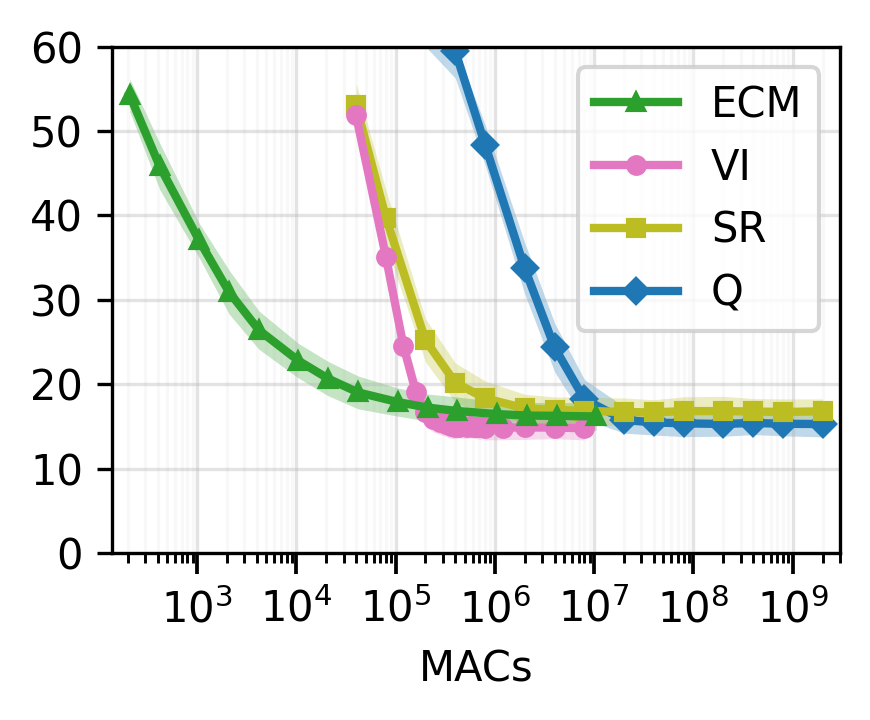

Saved: ./data_test/ns100_na2/steps_vs_macs_mean_std.png


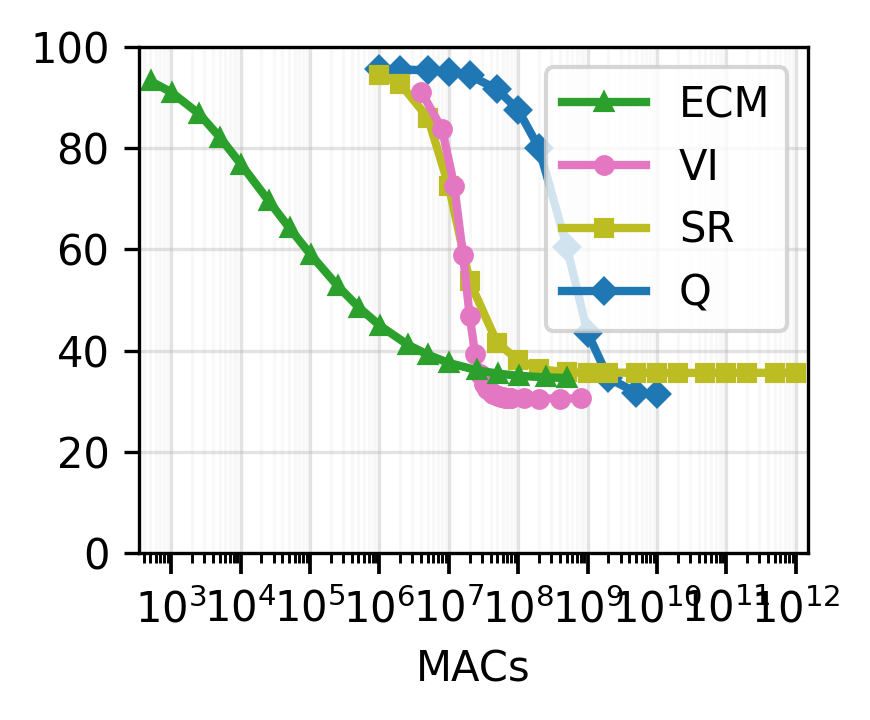

Saved: ./data_test/ns1000_na2/steps_vs_macs_mean_std.png


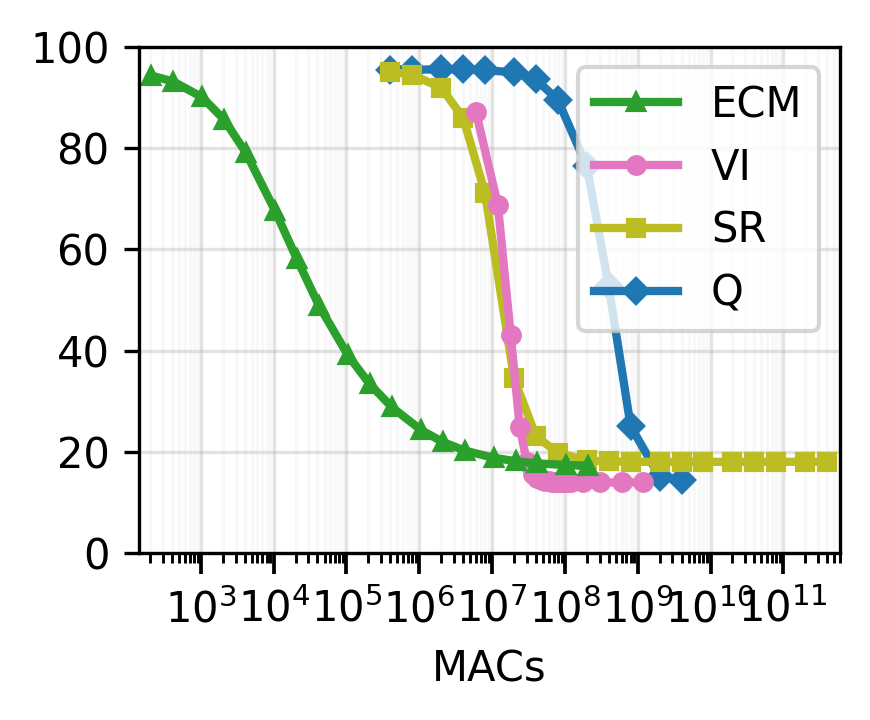

Saved: ./data_test/ns1000_na3/steps_vs_macs_mean_std.png


In [43]:
# Separate MAC figures for the three configurations
for cfg in CONFIGS:
    plot_mean_and_std(
        aggregate_results[cfg["name"]],
        cfg,
        x_metric="macs",
        x_label="MACs",
        output_name="steps_vs_macs_mean_std.png",
    )

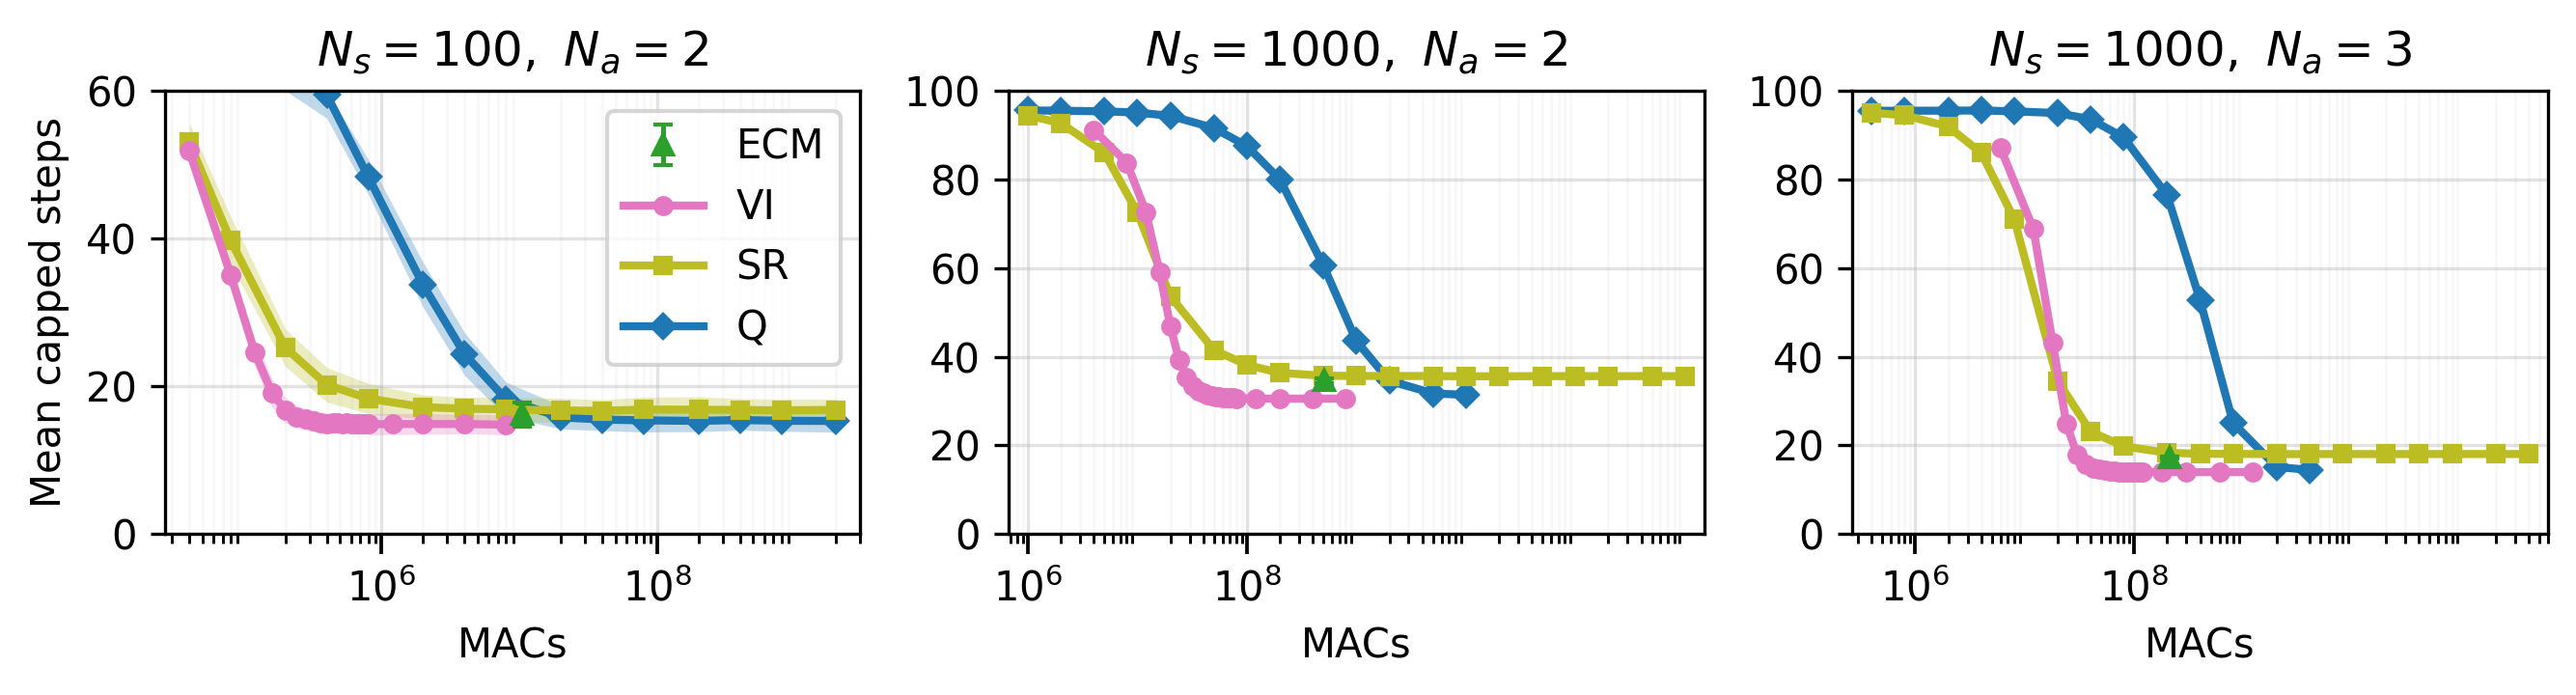

Saved: ./data_test/all_configurations_steps_vs_macs_mean_std.png


In [41]:
# Combined three-panel MAC figure
fig, axes = plt.subplots(
    1,
    3,
    figsize=(9, 2.5),
    dpi=300,
)

for index, cfg in enumerate(CONFIGS):
    plot_mean_and_std(
        aggregate_results[cfg["name"]],
        cfg,
        x_metric="macs",
        x_label="MACs",
        ax=axes[index],
        show_legend=(index == 0),
    )
    axes[index].set_title(cfg["label"])
    if index == 0:
        axes[index].set_ylabel("Mean capped steps")

fig.tight_layout()
combined_path = os.path.join(
    DATA_DIR,
    "all_configurations_steps_vs_macs_mean_std.png",
)
fig.savefig(combined_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", combined_path)

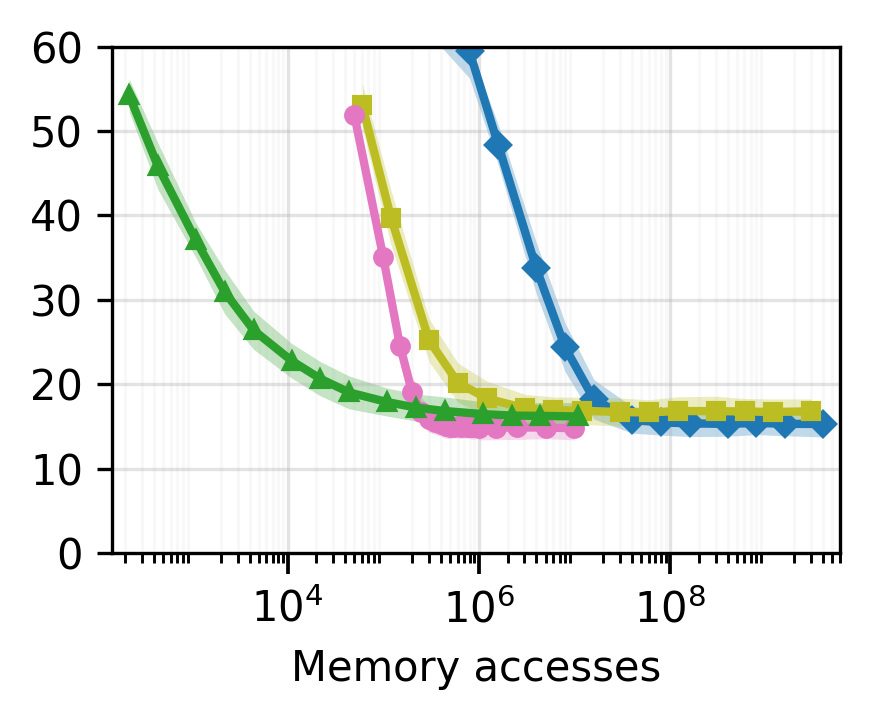

Saved: ./data_test/ns100_na2/steps_vs_memory_accesses_mean_std.png


/tmp/ipykernel_3556696/2852629603.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


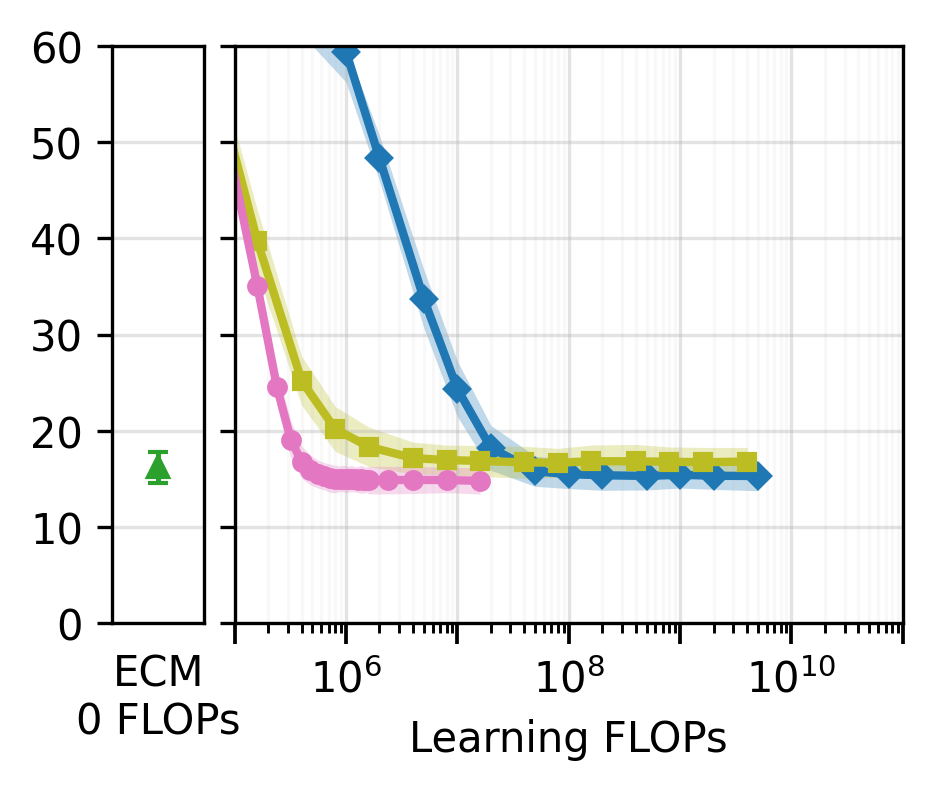

Saved: ./data_test/ns100_na2/steps_vs_flops_mean_std.png


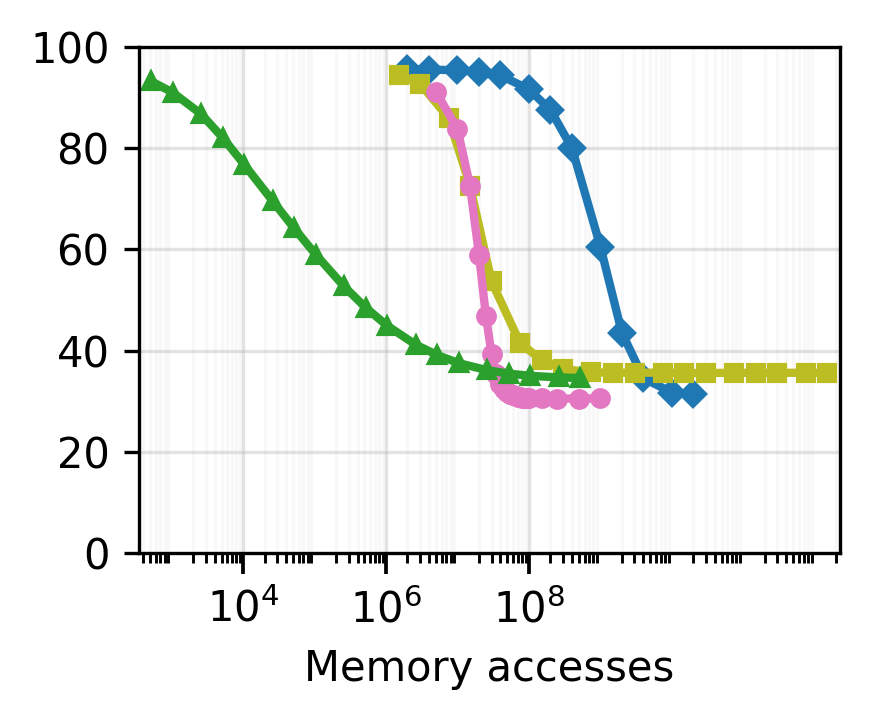

Saved: ./data_test/ns1000_na2/steps_vs_memory_accesses_mean_std.png


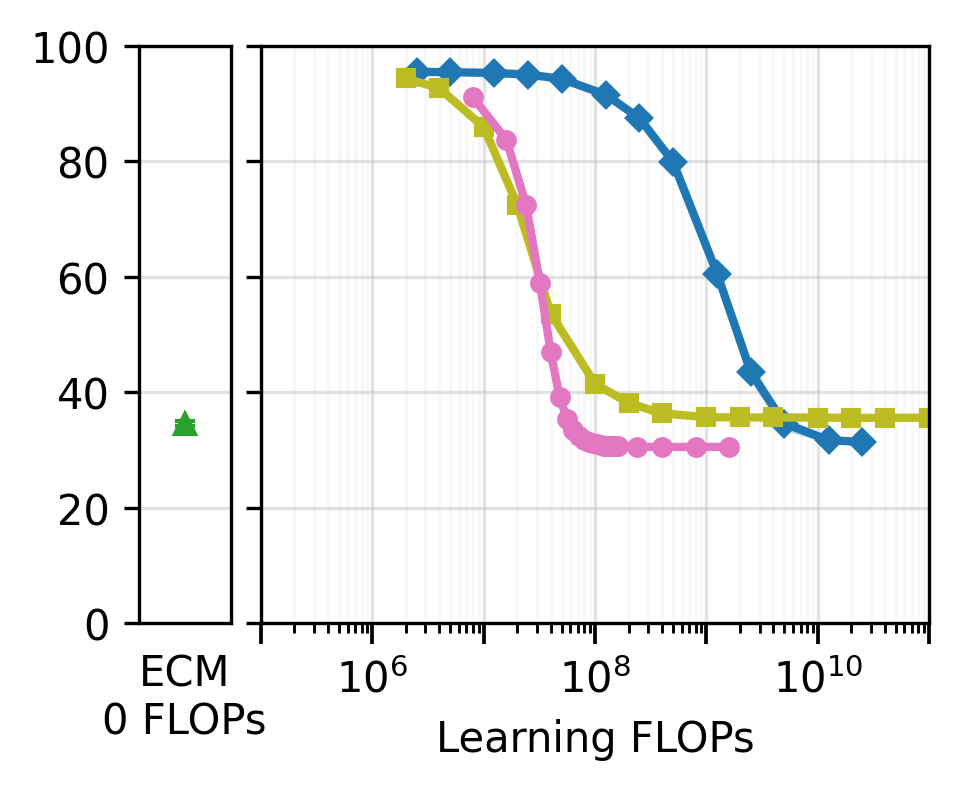

Saved: ./data_test/ns1000_na2/steps_vs_flops_mean_std.png


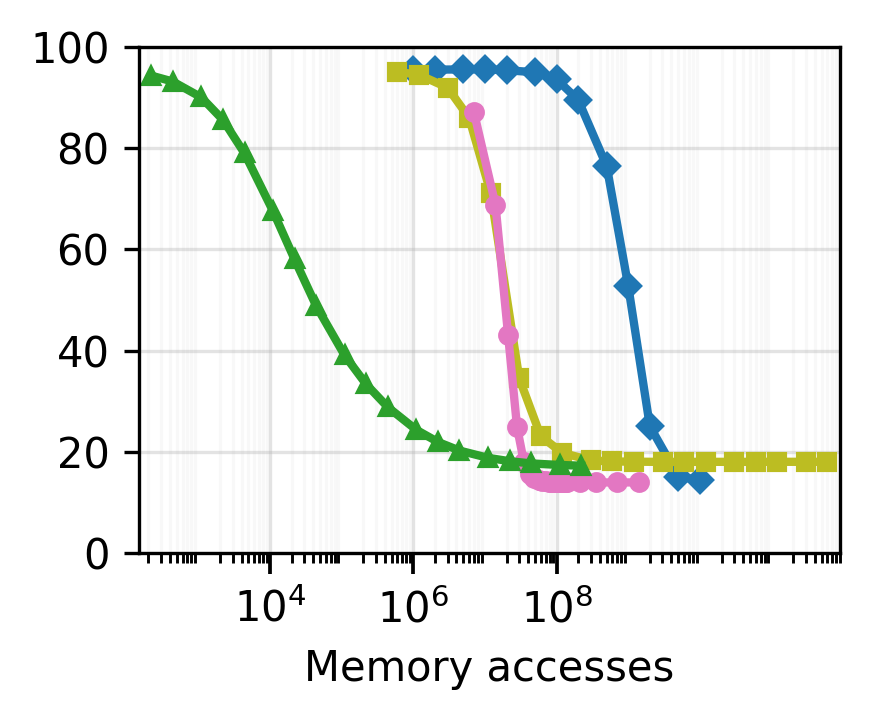

Saved: ./data_test/ns1000_na3/steps_vs_memory_accesses_mean_std.png


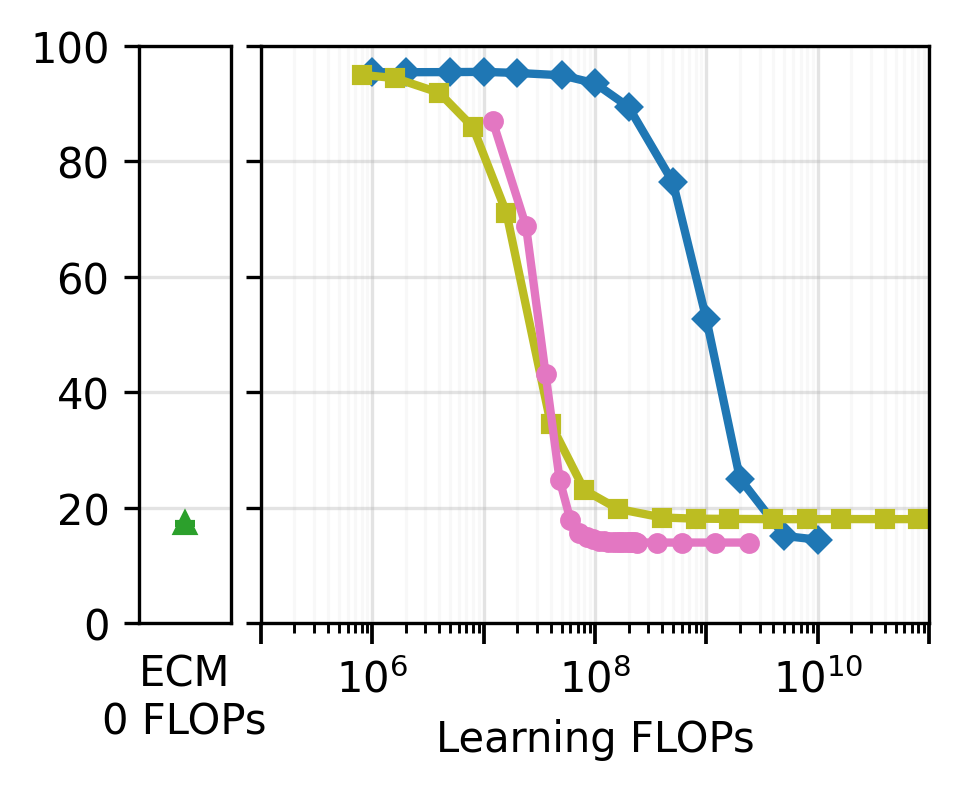

Saved: ./data_test/ns1000_na3/steps_vs_flops_mean_std.png


In [36]:
for cfg in CONFIGS:
    aggregate = aggregate_results[cfg["name"]]

    plot_mean_and_std(
        aggregate,
        cfg,
        x_metric="memory_accesses",
        x_label="Memory accesses",
        output_name="steps_vs_memory_accesses_mean_std.png",
        ecm_best_only=False,
        show_legend=False,
    )

    plot_flops_mean_and_std(
        aggregate,
        cfg,
        x_metric="flops",
        x_label="Learning FLOPs",
        output_name="steps_vs_flops_mean_std.png",
        show_legend=False,
        log_xmin=1e5,
        log_xmax=1e11,
        major_ticks=(1e5, 1e7, 1e9, 1e11),
    )

In [ ]:
# Inspect saved coverage. Each algorithm/checkpoint should report n_runs = 10.
coverage = all_aggregates[
    [
        "configuration",
        "algorithm",
        "checkpoint",
        "n_runs",
        "steps_mean",
        "steps_std",
    ]
]
display(coverage)
assert coverage["n_runs"].eq(NUM_REPEATS).all()